# __Quickstart__

In this notebook, we cover the basic usage of `adelie`.
We assume that the reader is familiar with the group elastic net problem.
For an introduction to group elastic net, we refer the readers to 
[Introduction to Group Elastic Net](./introduction.ipynb).

In [1]:
import adelie as ad
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix

## __Gaussian Group Elastic Net__

Before using `adelie`, we assume that the user has a feature matrix `X` and a response vector `y`.
For simplicity, we assume for now that `X` is a dense matrix,
although we will later see that `X` can be substituted with a custom matrix as well.
For demonstration, we will randomly generate our data.

In [2]:
n = 100     # number of observations
p = 1000    # number of features
seed = 0    # seed

np.random.seed(seed)
X = np.random.normal(0, 1, (n, p))
y = X[:, -1] * np.random.normal(0, 1) + np.random.normal(0, 1, n)

### __Lasso__

The most basic call to `ad.grpnet` simply supplies a `X` matrix and a `glm` object.
For example, `ad.glm.gaussian()` returns a Gaussian GLM object,
which corresponds to the usual least squares loss function.
By default, `ad.grpnet` will fit lasso by setting each feature as its own group.
`adelie` is written to treat groups of size `1` in a more optimized manner,
so it is a competitive lasso solver that has computation times similar to those of the `glmnet` package.
Like `glmnet`, `grpnet` will also generate a sequence of 100 regularizations $\lambda$ 
evenly spaced on the log scale by default if the user does not provide the path.
Since `grpnet` is a path-solver, it will warm-start at the next $\lambda$
using the current solution on the path.
__For this reason, we recommend users to supply a sufficiently fine grid of__ $\lambda$ __or use the default path!__

In [3]:
state = ad.grpnet(
    X=X,
    glm=ad.glm.gaussian(y=y),
)

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(
 46%|█████     | 46/100 [00:00:00<00:00:00, 6163.95it/s] [dev:90.5%]


Note that the solver finished early in this example.
We display a progress bar that indicates the number of $\lambda$'s processed,
time elapsed, time remaining, and the percent deviance explained.
By default, the solver terminates if the latter reaches $90\%$ as a simple heuristic to avoid overfitting.
This threshold can be controlled via the argument `adev_tol`.

The output of `ad.grpnet` is a _state_ object, which represents the state of the optimizer.
For most use-cases, the users do not need to inspect the [internals of a state object](https://jamesyang007.github.io/adelie/api_reference/generated/adelie.adelie_core.state.StateGaussianNaive32.html#adelie-adelie-core-state-stategaussiannaive32),
with some exceptions:

In [4]:
state.betas         # (L, p) sparse matrix of solutions (one for each row)
state.intercepts    # (L,) intercepts
state.devs          # (L,) vector of % deviance explained
state.lmdas         # (L,) regularization at each saved solution
assert True         # barrier to not output anything

Otherwise, we recommend users to use our diagnostic class,
`ad.diagnostic.diagnostic`, to visualize aspects of the state.

In [5]:
dg = ad.diagnostic.diagnostic(state=state)

For example, we can plot the coefficients and the percent deviance explained as a function of $-log(\lambda)$.

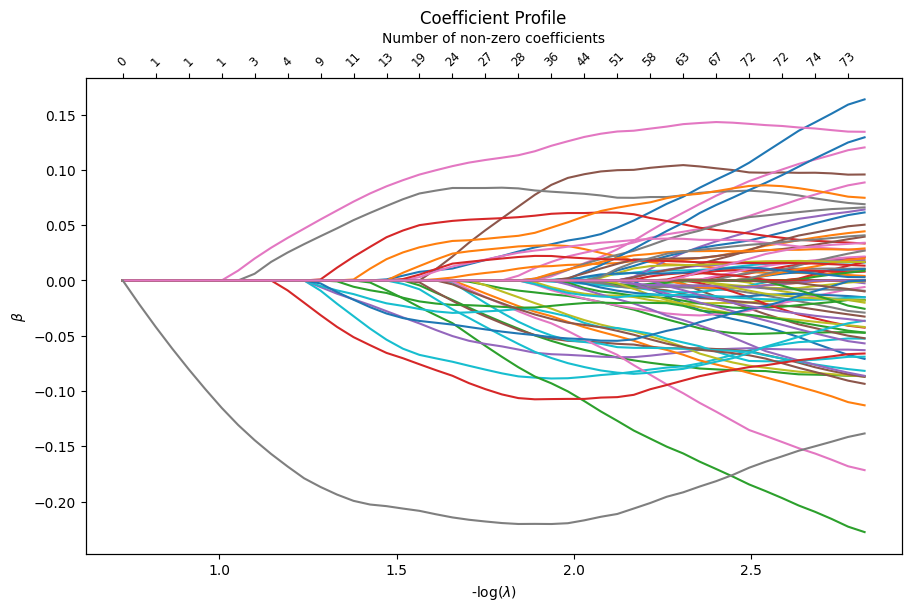

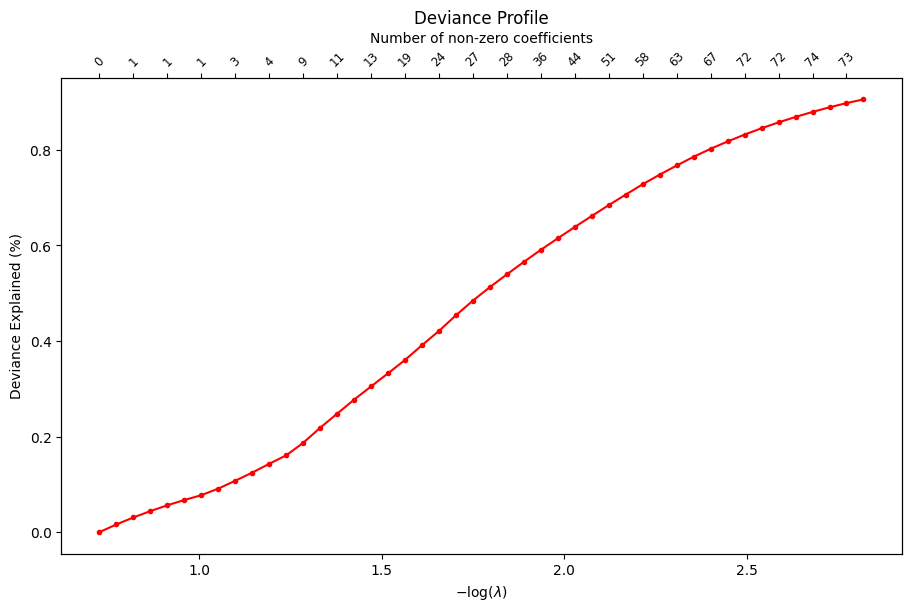

In [6]:
dg.plot_coefficients()
dg.plot_devs()
plt.show()

#### Standardization

By default, `adelie` leaves features unstandardized. To standardize a matrix `X`, use `ad.matrix.standardize(X)`. You may supply per-feature centers and scales; if omitted, they’re inferred from `X` as the column-wise mean and variance (with equal sample weights). One can standardize either an `adelie` matrix or a `Numpy` array.

In [7]:
ad.matrix.standardize(ad.matrix.dense(X))

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(


<adelie.matrix.standardize.<locals>._standardize at 0x15602fe20>

In [8]:
ad.matrix.standardize(X)

array([[ 1.76772357,  0.48173757,  0.97588274, ...,  0.08122465,
        -1.34600483, -0.17644806],
       [ 0.58970569,  0.92694663, -0.33382695, ...,  0.15771821,
        -1.33957503, -1.11909785],
       [-1.4471815 , -1.4282896 ,  0.10408185, ..., -0.26003096,
        -1.41909765,  0.0980949 ],
       ...,
       [ 0.05779507,  0.0822665 ,  0.49292964, ..., -0.75968619,
         0.26167226,  0.12142479],
       [ 2.06772862, -0.20551008,  1.39322485, ..., -1.36852011,
        -0.83270506,  0.69306616],
       [-0.01900891, -0.70359479,  0.23627697, ...,  0.8337461 ,
        -1.36877519, -1.09361108]])

It is recommended that a user standardizes their feature matrices before running `ad.grpnet`.

#### Predictions

We can make predictions at new values for the features — here we use a subset of the original. Call `adelie.diagnostic.predict` with the new matrix and the fitted slopes and intercepts from `state`. The result is an array of shape (`n_lambda`, `n_new`): one row per lambda along the path and one column per observation in the prediction matrix

In [9]:
newx = X[:5,]
pred = ad.diagnostic.predict(newx, betas = state.betas, intercepts = state.intercepts)

In [10]:
print("Predictions shape: ", pred.shape)
print("Number of regularization values: ", state.lmdas.shape[0])
print("Number of observations to predict: ", newx.shape[0])

Predictions shape:  (46, 5)
Number of regularization values:  46
Number of observations to predict:  5


When one elects to standardizes their data, one must be careful to also standardize the validation/test matrices with the same means and variances calculated from the training data. Here we can extract those attributes with `._mean` and `._scales` respectively.

In [11]:
standard_x = ad.matrix.standardize(ad.matrix.dense(X))

standardized_fit = ad.grpnet(
    X=standard_x,
    glm=ad.glm.gaussian(y=y),
)

 45%|████      | 45/100 [00:00:00<00:00:00, 5164.97it/s] [dev:90.0%]


Here we pass in the means and variances from `standard_x` when standardizing the matrix we will predict on.

In [12]:
newx = X[1:5,]
standard_new_x = ad.matrix.standardize(ad.matrix.dense(newx), \
                                       centers = standard_x._centers, scales = standard_x._scales)

In [13]:
pred_std = ad.diagnostic.predict(standard_new_x, betas = state.betas, intercepts = state.intercepts)
pred_std.shape

(46, 4)

#### Cross Validation

Finally, we would like to choose a good value for $\lambda$, and for that we use cross-validation. We include a `progress_bar` argument, which can be helpful for big problems. The cross-validation pipeline in `adelie` takes a couple of steps. First, one fits a `ad.cv.cv_grpnet` object, which takes in similar parameters to the already familiar `ad.grpnet`. The user has the option to specify the number of CV folds and the number of regularizations in the path. 

In [14]:
fitcv = ad.cv.cv_grpnet(X, glm=ad.glm.gaussian(y=y), progress_bar = True)

100%|██████████| 100/100 [00:00:00<00:00:00, 7750.21it/s] [dev:95.6%]


This, in turn, returns a `CVGrpnetResult`, which holds the result of K-fold CV group elastic net. The `plot_loss` method for a `cv.cv_grpnet` object displays the average cross-validated deviance of the model, with approximate standard error bars for the average.

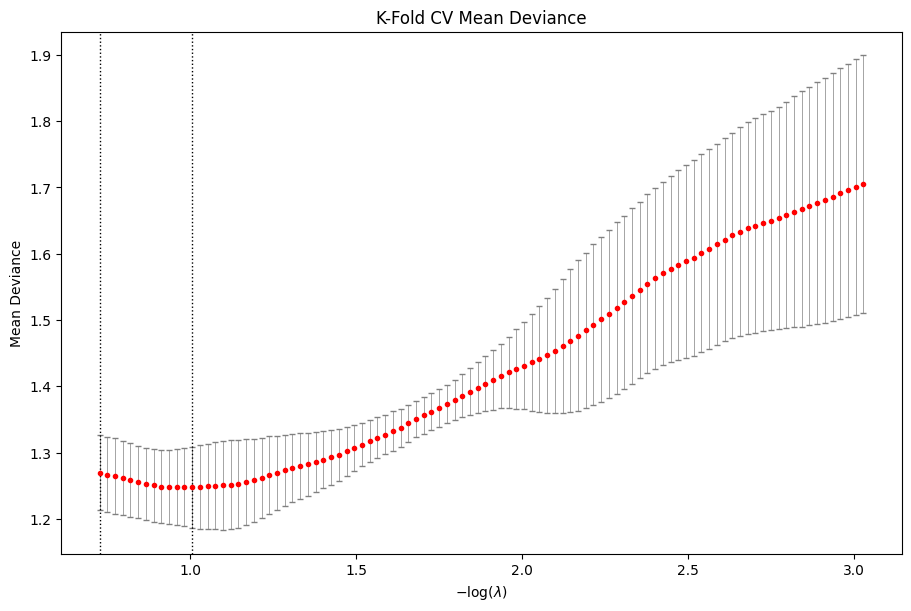

In [15]:
fitcv.plot_loss();

Two vertical dashed lines are included: one at the value of $\lambda$ corresponding to the minimum value, and another at a larger (more conservative) value of $\lambda$, such that the mean error is within one standard error of the minimum.

One can print the regularization path used for all folds, as well as the average CV loss at each lambda across all folds. Calling `best_idx` will return the argmin of `avg_losses`. Be aware of the loss function used by `adelie` (see [here](https://jamesyang007.github.io/adelie/user_guide/notebooks/introduction.html#Single-Response-Group-Elastic-Net)) that produces negative values, indicating better performance.

In [16]:
print("The lambda with the lowest average CV loss has index: ", fitcv.best_idx)
fitcv.avg_losses

The lambda with the lowest average CV loss has index:  12


array([-0.00022383, -0.00141276, -0.00252765, -0.00395016, -0.00551796,
       -0.00704539, -0.00852039, -0.00963945, -0.01045344, -0.01081417,
       -0.01094587, -0.01101557, -0.01107775, -0.01070461, -0.0102704 ,
       -0.00980347, -0.00958058, -0.00905938, -0.00834766, -0.00730115,
       -0.00579683, -0.003848  , -0.00200346, -0.00033188,  0.00189273,
        0.00351659,  0.00487495,  0.00618934,  0.00799936,  0.0097885 ,
        0.01151046,  0.01361481,  0.01616278,  0.01871432,  0.0211038 ,
        0.02366423,  0.02632814,  0.02875139,  0.03135816,  0.03389454,
        0.03721296,  0.04044142,  0.04338895,  0.04590866,  0.04871082,
        0.05182387,  0.05488234,  0.05801367,  0.0609041 ,  0.06387666,
        0.066984  ,  0.06973896,  0.07274935,  0.07555081,  0.07808176,
        0.08070015,  0.08325669,  0.08587109,  0.08851368,  0.09178304,
        0.0955398 ,  0.09947661,  0.10323916,  0.10720503,  0.11164729,
        0.11566426,  0.11974669,  0.12415529,  0.12846595,  0.13

Once we have a `CVGrpnetResult`, we can rerun the group elastic net until the best CV $\lambda$ generated by our solver. This returns another `state` object, just like `ad.grpnet`. Thus, we can predict in the same fashion as above, but now with a more apt regularization parameter.

In [17]:
refitcv = fitcv.fit(X, glm=ad.glm.gaussian(y=y))

100%|██████████| 13/13 [00:00:00<00:00:00, 2156.87it/s] [dev:7.7%]


In [18]:
refitcv.lmda_path

array([0.48327604, 0.4721655 , 0.4613104 , 0.45070485, 0.44034313,
       0.43021962, 0.42032885, 0.41066547, 0.40122426, 0.39200009,
       0.38298799, 0.37418308, 0.3655806 ])

In [19]:
newx = X[:5,]
pred_cv = ad.diagnostic.predict(newx, betas = refitcv.betas, intercepts = refitcv.intercepts)

If we want to just see the predictions at the best $\lambda$, we can subset the coefficients and intercepts with the best index identified from the `CVGrpnetResult`.

In [20]:
pred_cv_best_lam = ad.diagnostic.predict(newx, \
                    betas = refitcv.betas[fitcv.best_idx], intercepts = refitcv.intercepts[fitcv.best_idx])
pred_cv_best_lam.shape

(1, 5)

### __Group Lasso__





To fit group lasso, the user simply needs to supply a `groups` argument that
defines the starting column index of $X$ for each group.
For example, if there are `4` features with two (contiguous) groups of sizes `3` and `1`, respectively,
then `groups = [0, 3]`.
For demonstration, we take the same data as before and group every `10` features.
We then fit group lasso using the same function.

In [21]:
10*np.arange(X.shape[-1] // 10)

array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120,
       130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250,
       260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380,
       390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510,
       520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640,
       650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770,
       780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900,
       910, 920, 930, 940, 950, 960, 970, 980, 990])

In [22]:
state = ad.grpnet(
    X=X,
    glm=ad.glm.gaussian(y=y),
    groups=10*np.arange(X.shape[-1] // 10),
)

 38%|████      | 38/100 [00:00:00<00:00:00, 3938.66it/s] [dev:90.2%]


In [23]:
state.groups

array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120,
       130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250,
       260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380,
       390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510,
       520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640,
       650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770,
       780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900,
       910, 920, 930, 940, 950, 960, 970, 980, 990])


As before, we may inspect the same elements of `state` and diagnostics.

In [24]:
dg = ad.diagnostic.diagnostic(state=state)

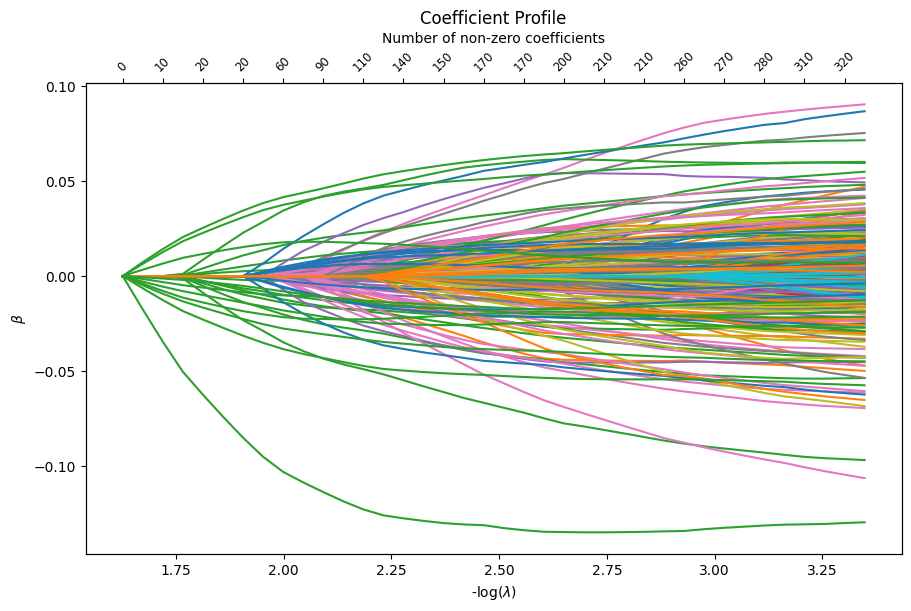

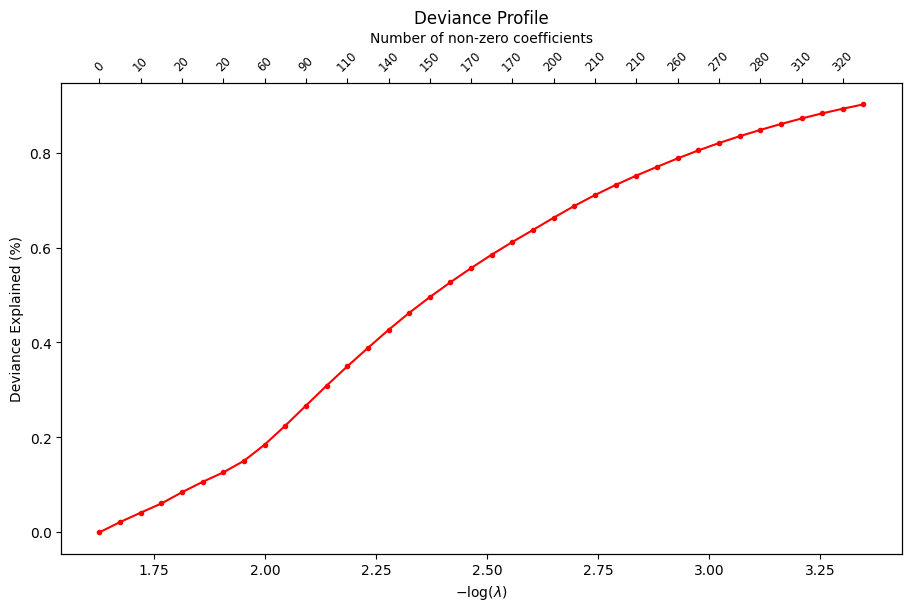

In [25]:
dg.plot_coefficients()
dg.plot_devs()
plt.show()

As before, we can use cross-validation to select the tuning parameter.

In [26]:
fitgcv = ad.cv.cv_grpnet(
    X=X,
    glm=ad.glm.gaussian(y=y),
    groups=10*np.arange(X.shape[-1] // 10),
    progress_bar = True
)
print("The lambda with the lowest average CV loss is: ", fitgcv.best_idx)

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(
100%|██████████| 100/100 [00:00:00<00:00:00, 6643.07it/s] [dev:86.0%] 


The lambda with the lowest average CV loss is:  46


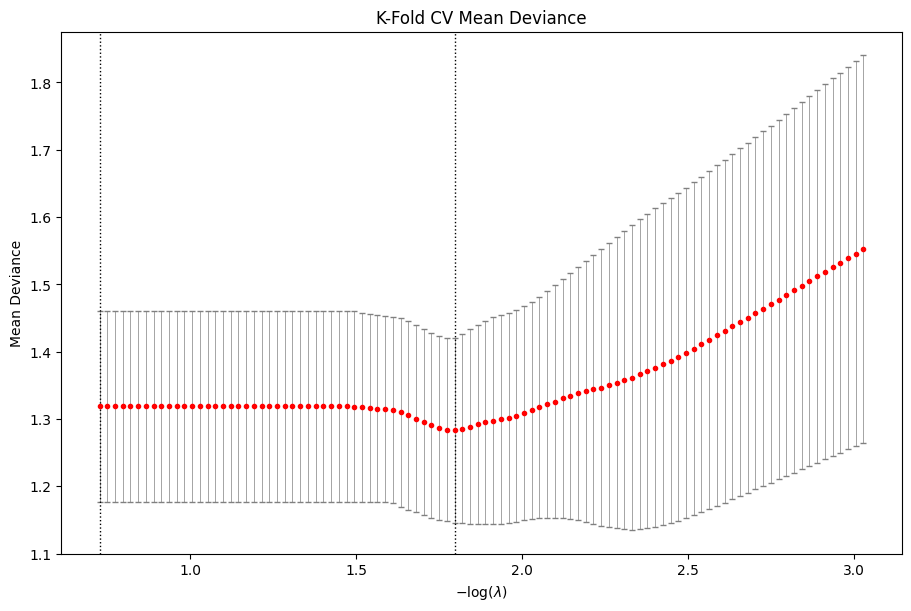

In [27]:
fitgcv.plot_loss();

## __GLM Group Elastic Net__

In the previous section, we covered how to solve penalized least squares regression.
Nearly all of the content remains the same for fitting penalized GLM regression.
The only difference is in the choice of the `glm` object.
For brevity, we only discuss logistic regression as our non-trivial GLM example,
however the following discussion applies for any GLM.

Let's generate our dataset for logistic regression.

In [28]:
n = 100     # number of observations
p = 1000    # number of features
seed = 1    # seed

np.random.seed(seed)
X = np.random.normal(0, 1, (n, p))
eta = X[:, -1] * 1
mu = 1 / (1 + np.exp(-eta))
y = np.random.binomial(1, mu)

To solve the group elastic net problem using the logistic loss,
we simply provide the Binomial GLM object.
For simplicity, we fit the lasso problem below.

 59%|██████    | 59/100 [00:00:00<00:00:00, 4137.40it/s] [dev:90.2%]


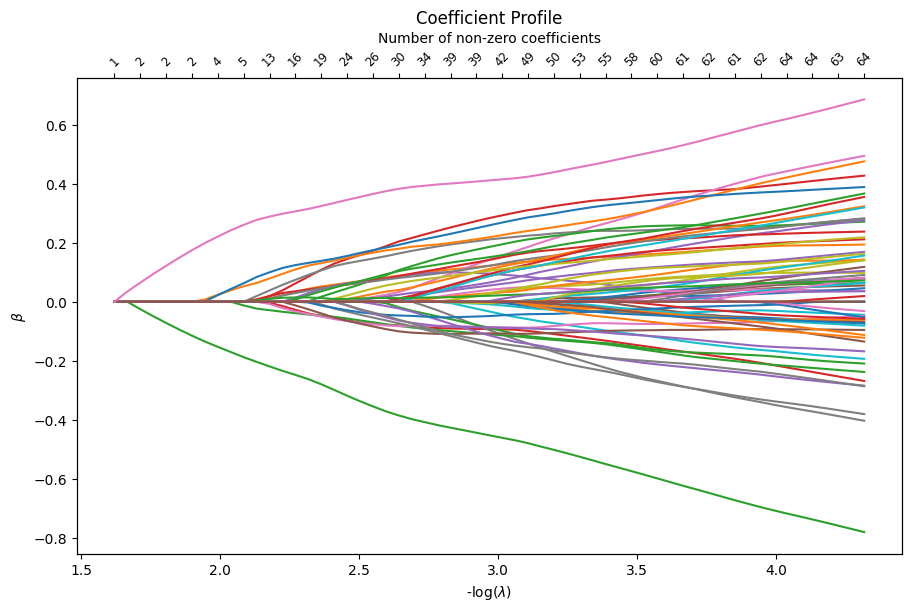

In [29]:
state = ad.grpnet(
    X=X,
    glm=ad.glm.binomial(y=y, dtype=np.float64),
)

dg = ad.diagnostic.diagnostic(state=state)
dg.plot_coefficients();

As before, the user may inspect diagnostic elements of the state in the same fashion. Cross-validation also works as before:

In [30]:
fitbcv = ad.cv.cv_grpnet(
    X=X,
    glm=ad.glm.binomial(y=y, dtype=np.float64),
    progress_bar = True
)

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(
100%|██████████| 102/102 [00:00:00<00:00:00, 7697.31it/s] [dev:87.7%]


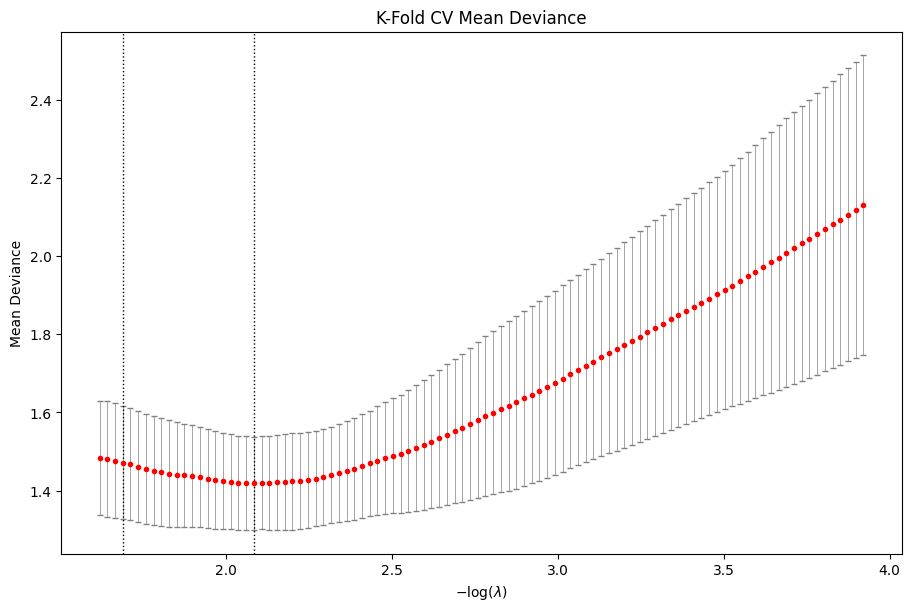

In [31]:
fitbcv.plot_loss();

We can make predictions from the fitted objects as before. Here we use the best $\lambda$ value identified by `fitbcv`.

In [32]:
glm_binomial = ad.glm.binomial(y=y, dtype=np.float64)

refitbcv = fitbcv.fit(
    X, 
    glm=glm_binomial
)

pred_bcv = ad.diagnostic.predict(
    newx, 
    betas = refitbcv.betas[fitbcv.best_idx], 
    intercepts = refitbcv.intercepts[fitbcv.best_idx]
)

pred_bcv

100%|██████████| 21/21 [00:00:00<00:00:00, 3954.71it/s] [dev:12.8%]


array([[-0.17188447, -0.58328388, -0.42351621, -0.17675563,  0.22788826]])

For GLMs, the predictions are by default on the link ($\eta$) scale. However, one can also make predictions on the inverse link or response scale ($\mu$):



In [33]:
probs = np.zeros_like(pred_bcv.ravel())  # Allocate an array for inverse-link predictions
glm_binomial.inv_link(pred_bcv, probs)    # Apply the inverse link function 

probs

array([0.45713437, 0.35817732, 0.39567566, 0.45592578, 0.55672678])

For the Gaussian–identity case, the link and response scales coincide, so the values are unchanged.
This method is useful for non-identity links (e.g. log), where `inv_link` will transform 
$\eta$ into $\mu$ appropriately.

## __Multi-Response GLM Elastic Net__

### MultiGaussian (Multi-task Response with Squared Error Loss)

`ad.grpnet` is also able to fit multi-response GLM elastic nets.
Currently, we only support MultiGaussian (least squares) and Multinomial GLMs.
The only difference in the API from the single-response case 
is that `groups` argument only takes two possible values:
`"grouped"` or `"ungrouped"`.
If `groups = "grouped"` (default), then for each feature, 
the corresponding coefficients across the responses are grouped.
Otherwise, every coefficient is in its own group.

The following code shows an example of fitting a multi-response least squares group elastic net.
For simplicity, we fit the lasso problem.

In [34]:
n = 100     # number of observations
p = 1000    # number of features
K = 4       # number of responses
seed = 0    # seed

np.random.seed(seed)
X = np.random.normal(0, 1, (n, p))
y = X[:, -1:] @ np.random.normal(0, 1, (1, K)) + np.random.normal(0, 1, (n, K))

In [35]:
state = ad.grpnet(
    X=X,
    glm=ad.glm.multigaussian(y=y),
)

 61%|██████    | 61/100 [00:00:00<00:00:00, 2836.12it/s] [dev:90.2%]


Another important difference from the single-response case is that 
the user must be aware of the shape of the returned coefficients.
For multi-response GLMs, the intercept (if `intercept=True`) is added for each response.
Hence, `state.intercepts` will be a `(L, K)` matrix.
Moreover, `state.betas` will be a `(L, pK)` sparse matrix where every `K` columns correspond to the
coefficients associated with a feature and across all responses.
So, `state.betas[i, :K]` are the coefficients for the `i` th solution on the path and first feature.

In [36]:
(
    state.intercepts.shape,
    state.betas.shape,
)

((61, 4), (61, 4000))

Here, if we plot the coefficient path, we see four coefficients enter at the start of the path. This is just a multi-task Lasso and the first four coefficient correspond to each of the 4 responses.

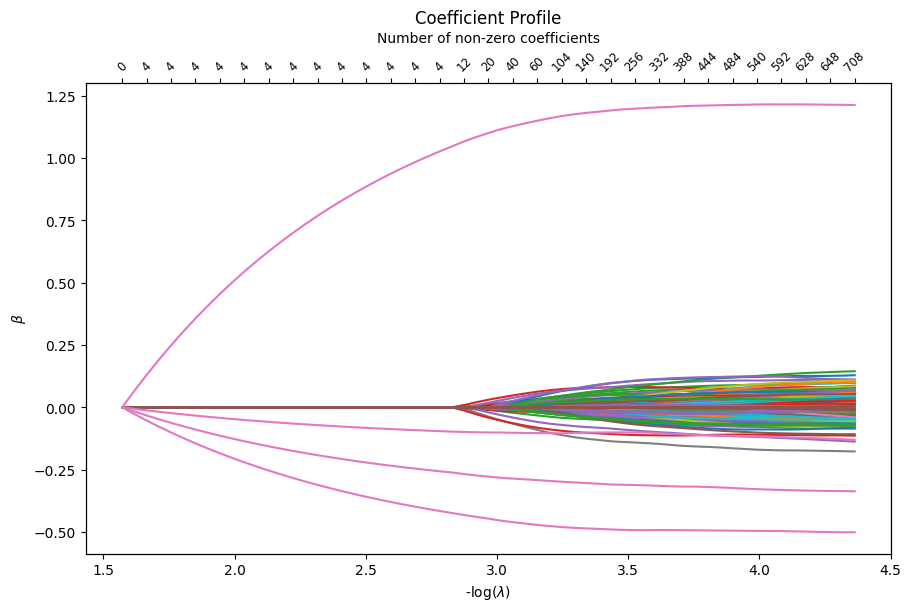

In [37]:
dg = ad.diagnostic.diagnostic(state=state)
dg.plot_coefficients();

We can produce the plot showing the $\ell_2$ of each coefficient group as well by setting `l2_norm` to `True`. This may be more intuitive to visualize since there is only one path associated with a group.

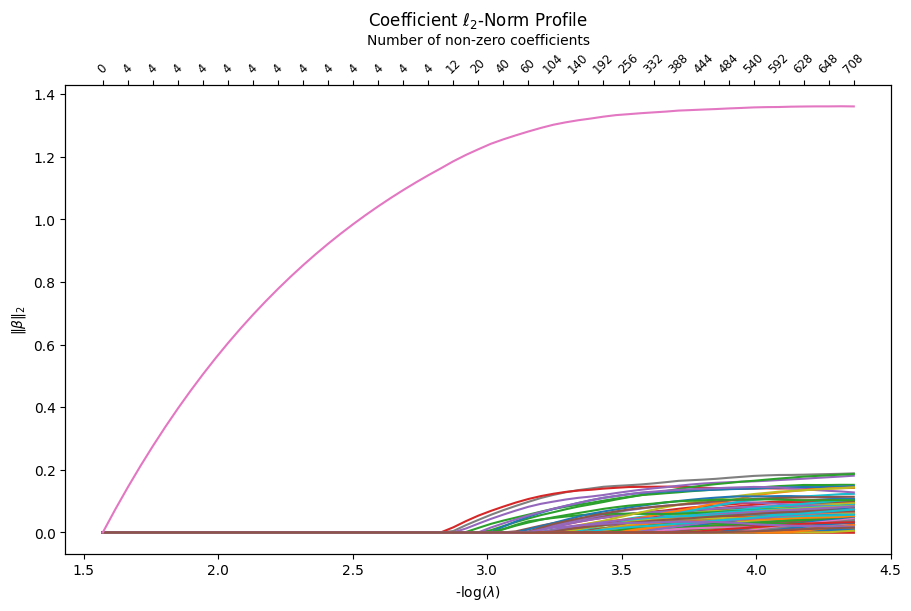

In [38]:
dg.plot_coefficients(l2_norm = True);

### Multinomial

For completion, we show an example of fitting a multinomial group elastic net.
For simplicity, we fit the lasso problem.

The following code shows an example of fitting a multinomial regression problem. We use the `glm.multinomial()` family, which expects a matrix response $Y$ with $K$ columns (the number of classes). Each row of $Y$ is a proportion vector which sums to 1. In the example below, $Y$ is an indicator matrix, with a single 1 in each row, the rest being zeros. If instead the data were grouped, and each row originally represented the number out of $n_i$ in category $k$, we would first divide each of the counts by $n_i$ turning them into proportions. Then we would supply weights $w_i = n_i$ normalized to sum to 1.0 overall.



In [39]:
n = 300     # number of observations
p = 100     # number of features
K = 4       # number of responses
seed = 0    # seed

np.random.seed(seed)
X = np.random.normal(0, 1, (n, p))
eta = X[:, -4:] @ (np.tile(np.arange(1, 5), (4, 1)))
mu = np.exp(eta) / np.sum(np.exp(eta), axis=-1)[:, None]
y = np.array([np.random.multinomial(1, m) for m in mu])

The fitting proceeds as before. We will directly fit a group lasso, with groups of 5 chosen simlarly to before.

In [40]:
grps = np.arange(0, p, 5)
fitm = ad.grpnet(
    X=X,
    glm=ad.glm.multinomial(y=y, dtype=np.float64),
    groups=grps
)

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(
 95%|█████████ | 95/100 [00:00:00<00:00:00, 226.77it/s] [dev:90.2%]


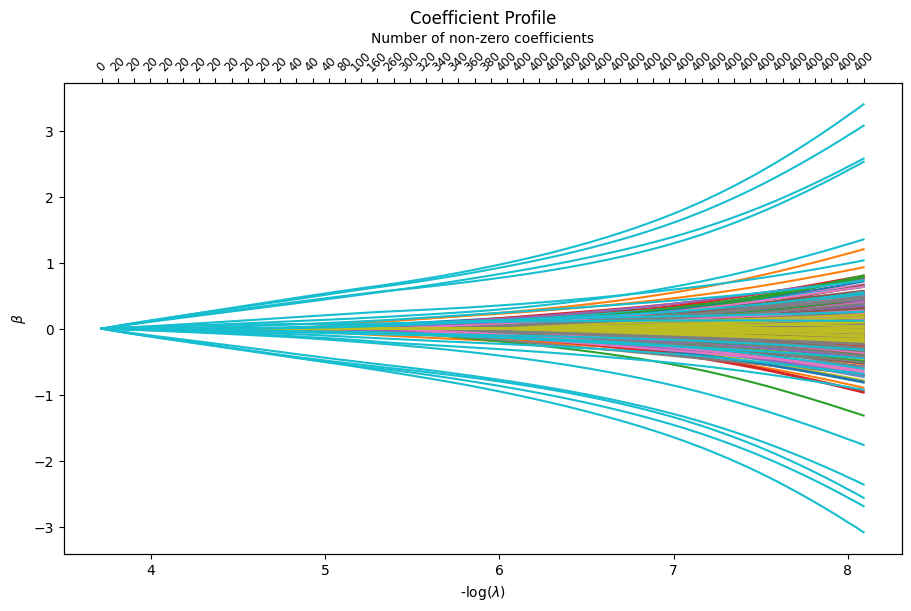

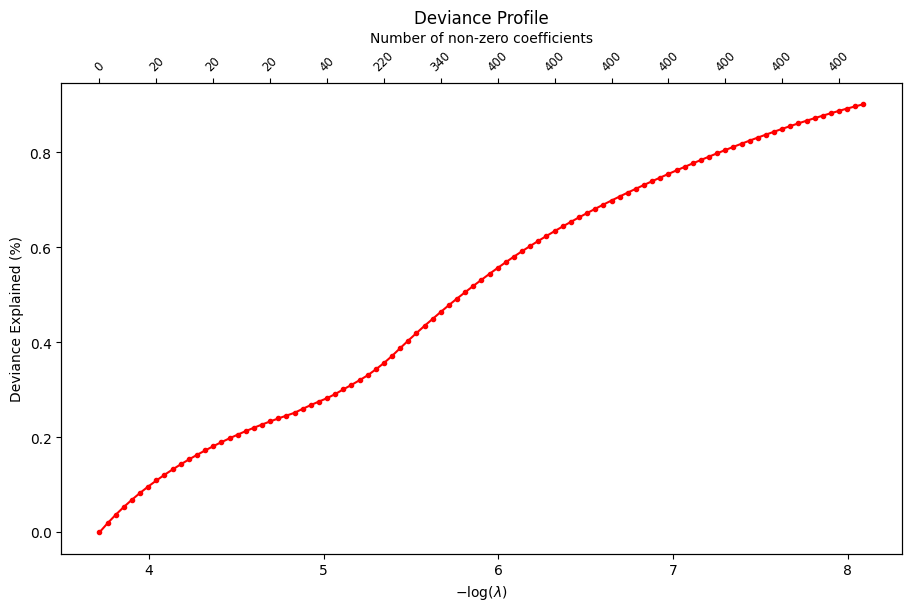

In [127]:
dg = ad.diagnostic.diagnostic(state=fitm)
dg.plot_coefficients(top_axis_step = 2); #optional argument changes the spacing of the numbers included along the top axis
dg.plot_devs(top_axis_step = 7);

The coefficient for each feature is a vector (one per class), so rather than show multiple coefficients, the plot shows the progress of the 2norm of this vector as a function of $\lambda$. Once again, because of the grouping (into groups of 5 here), the groups are colored the same.

In [42]:
fitmcv = ad.cv.cv_grpnet(
    X=X,
    glm=ad.glm.multinomial(y=y, dtype=np.float64),
    progress_bar = True
)

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(
100%|██████████| 101/101 [00:00:00<00:00:00, 908.86it/s] [dev:58.0%]


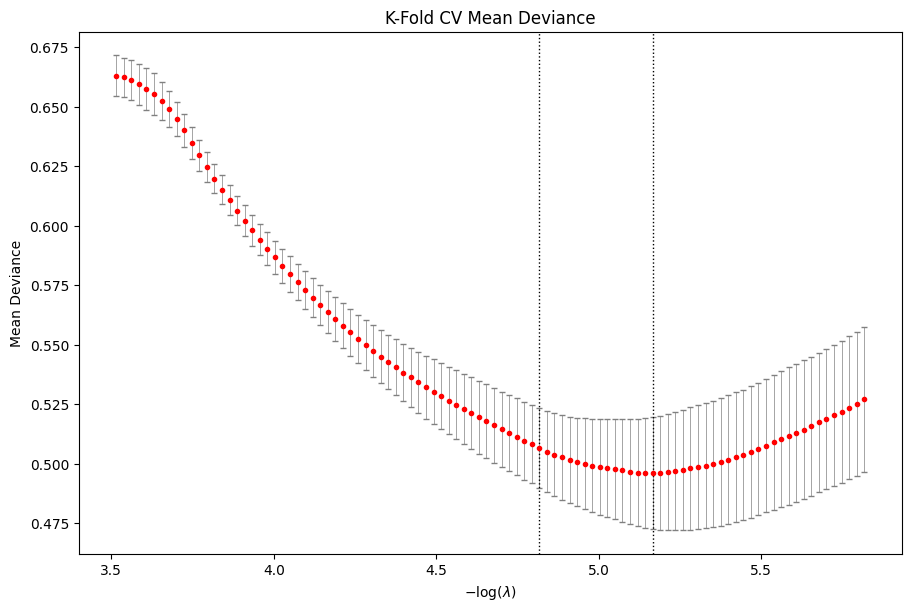

In [43]:
fitmcv.plot_loss();

Another important difference from the single-response case is that the user must be aware of the shape of the returned coefficients.

In [44]:
fitm.intercepts.shape

(95, 4)

For multi-response GLMs, the `intercepts` component is included by default for each response, and hence is a $L \times K$ matrix, where $L$ is the number of $\lambda$s in the path. The `betas` component will be a $L \times pK$ sparse matrix where every successive $K$ columns correspond to the coefficients associated with a feature and across all responses

Fortunately the `predict()` method understands this structure, and behaves as intended.

In [45]:
glm_multinom = ad.glm.multinomial(y=y, dtype=np.float64)

refitmcv = fitmcv.fit(
    X=X,
    glm = glm_multinom
)

pred_mcv = ad.diagnostic.predict(
    X[1:3,], 
    betas = refitmcv.betas,
    intercepts = refitmcv.intercepts
)


100%|██████████| 72/72 [00:00:00<00:00:00, 1853.12it/s] [dev:35.7%]


In [46]:
min_lam_predictions = pred_mcv[fitmcv.best_idx]
min_lam_predictions

array([[-2.56573753, -1.67906485,  0.39814986,  3.25748018],
       [-0.36194949, -0.41765547, -0.25549029,  0.44430721]])

For the multi-response GLM, we find the prediction at the best $\lambda$ after all the predictions are made.

Typically for the multinomial we would be more interested in the predicted probabilities:

In [47]:
inv_link_multi = np.zeros_like(min_lam_predictions)
proba = glm_multinom.inv_link(min_lam_predictions, inv_link_multi)

inv_link_multi

array([[0.00277117, 0.00672575, 0.05368628, 0.93681681],
       [0.18876263, 0.17853494, 0.20996681, 0.42273563]])

Each of the rows sum to 1.

In [48]:
np.sum(inv_link_multi, axis = 1)

array([1., 1.])

## Cox Models

Our final example will be for censored survival data, and we will fit Cox proportional hazards model.



We create an example with a 500×100 sparse $X$ matrix for demonstration purposes. See the secion on Sparse Matrices below for more details. In this example we have right censoring. So the “subject” exits at times in $y$, and the binary `status` is 1 if the exit is a “death”, else 0 if censored.



In [49]:
import adelie as ad
import numpy as np
from scipy.sparse import coo_matrix

In [50]:
n = 500     # number of observations
p = 100    # number of features
seed = 0    # seed
np.random.seed(0)

# Dense design matrix ~ N(0,1)
nnz = (n * p) // 2  # 50% nonzeros

flat = np.random.choice(n * p, size=nnz, replace=False)
i = flat // p
j = flat % p
x = np.random.normal(0, 1, size=nnz)

X_sparse = coo_matrix((x, (i, j)), shape=(n, p)).tocsr()
X_sparse = ad.matrix.sparse(X_sparse)

nzc = p // 4
beta = np.random.normal(size=nzc)
fx = (X_sparse[:, :nzc] @ beta) / 3.0
hx = np.exp(fx)
y = np.random.exponential(size=n) / hx
status = np.random.binomial(n=1, p=0.3, size=n)

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:1353: UserWarning: Converting to CSC format.
  warnings.warn("Converting to CSC format.")


We now fit an elastic-net model using the `glm.cox()` family, with every set of 5 coefficients in a group.



In [51]:
grps = np.arange(0, p, 5)
glm_cox = ad.glm.cox(stop=y, status = status, dtype=np.float64)

fit_cox1 = ad.grpnet(
    X=X_sparse,
    glm=glm_cox,
    alpha = 0.5,
    groups = grps
)

100%|██████████| 100/100 [00:00:00<00:00:00, 447.17it/s] [dev:13.0%]


In [52]:
lam_path = fit_cox1.lmda_path
lam_path

array([0.07686443, 0.07337082, 0.070036  , 0.06685276, 0.0638142 ,
       0.06091374, 0.05814512, 0.05550234, 0.05297967, 0.05057166,
       0.0482731 , 0.04607901, 0.04398465, 0.04198548, 0.04007718,
       0.03825561, 0.03651683, 0.03485708, 0.03327278, 0.03176048,
       0.03031691, 0.02893896, 0.02762364, 0.02636811, 0.02516963,
       0.02402564, 0.02293363, 0.02189126, 0.02089627, 0.01994651,
       0.01903991, 0.01817451, 0.01734845, 0.01655994, 0.01580726,
       0.0150888 , 0.01440299, 0.01374835, 0.01312347, 0.01252699,
       0.01195762, 0.01141412, 0.01089533, 0.01040012, 0.00992742,
       0.00947621, 0.0090455 , 0.00863437, 0.00824192, 0.00786731,
       0.00750973, 0.0071684 , 0.00684259, 0.00653158, 0.00623471,
       0.00595133, 0.00568084, 0.00542263, 0.00517617, 0.0049409 ,
       0.00471633, 0.00450197, 0.00429734, 0.00410202, 0.00391558,
       0.00373761, 0.00356773, 0.00340557, 0.00325078, 0.00310303,
       0.00296199, 0.00282737, 0.00269886, 0.00257619, 0.00245

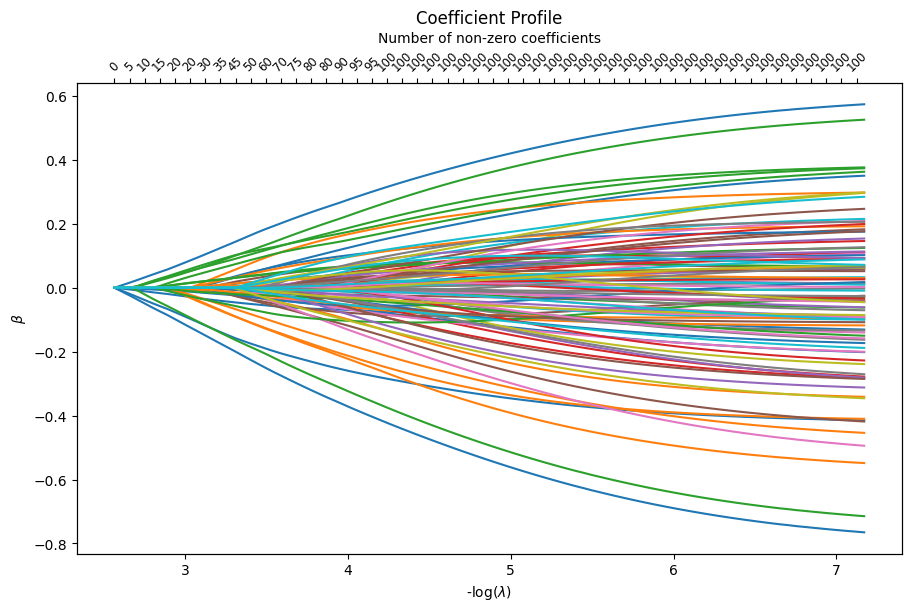

In [53]:
dg = ad.diagnostic.diagnostic(state=fit_cox1)
dg.plot_coefficients();

In [54]:
np.random.seed(0)

grps = np.arange(0, p, 5)
glm_cox = ad.glm.cox(stop=y, status = status, dtype=np.float64)

fit_cox = ad.cv.cv_grpnet(
    X=X_sparse,
    glm=glm_cox,
    alpha = 0.5,
    groups = grps
)

refit_cox = fit_cox.fit(
    X=X_sparse,
    glm = glm_cox,
    alpha = 0.5,
    groups = grps
)

100%|██████████| 35/35 [00:00:00<00:00:00, 788.41it/s] [dev:6.0%]


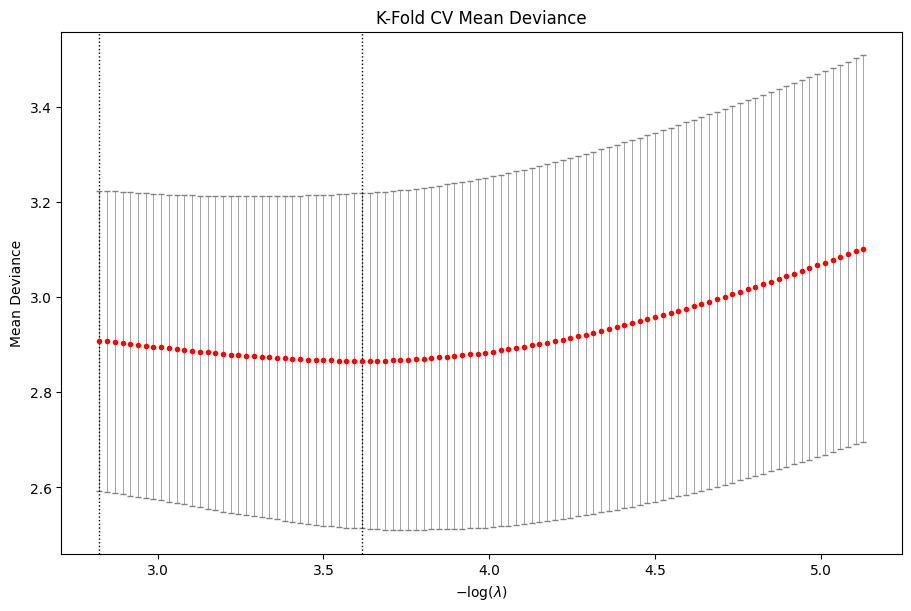

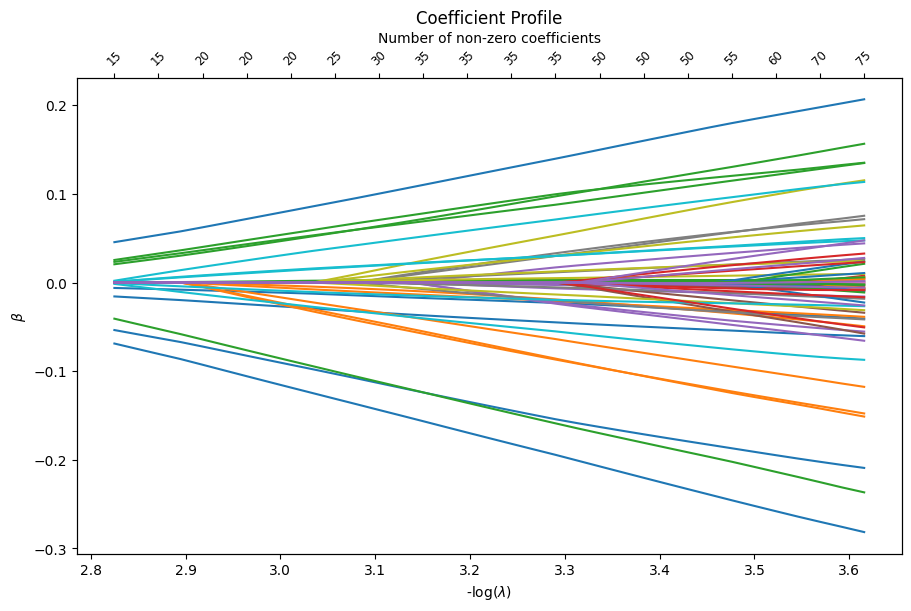

In [55]:
fit_cox.plot_loss();
dg = ad.diagnostic.diagnostic(state=refit_cox)
dg.plot_coefficients();

The family `ad.glm.cox()` accommodates start-stop data and strata as well. It handles ties by default using the “Efron” method. See [ad.glm.cox](https://jamesyang007.github.io/adelie/generated/adelie.glm.cox.html#adelie-glm-cox) for further details.

## __Constraints__

Adelie supports *box constraints* (lower and upper bounds on coefficients). Here we demonstrate with a few examples. Currently only works with scalar response models.

### Non-negative Lasso

For our first example we will fit a non-negative lasso, using randomly generated data. Note that even though it seems the constraint object is the same for each singleton group, they need to be created separately; i.e. we cannot make one, and replicate it. This is somewhat counter-intuitive, but these are the rules.



In [56]:
n = 100     # number of observations
p = 30    # number of features
seed = 1    # seed

np.random.seed(seed)
X = np.random.normal(0, 1, (n, p))
y = X[:, -1] * np.random.normal(0, 1) + np.random.normal(0, 1, n)

In [57]:
fit = ad.grpnet(X, ad.glm.gaussian(y=y))
constr = [ad.constraint.lower(b=np.array([0.0])) for _ in range(p)]

fit_constr = ad.grpnet(X, ad.glm.gaussian(y=y), constraints = constr)

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(
100%|██████████| 100/100 [00:00:00<00:00:00, 39183.68it/s] [dev:18.0%]


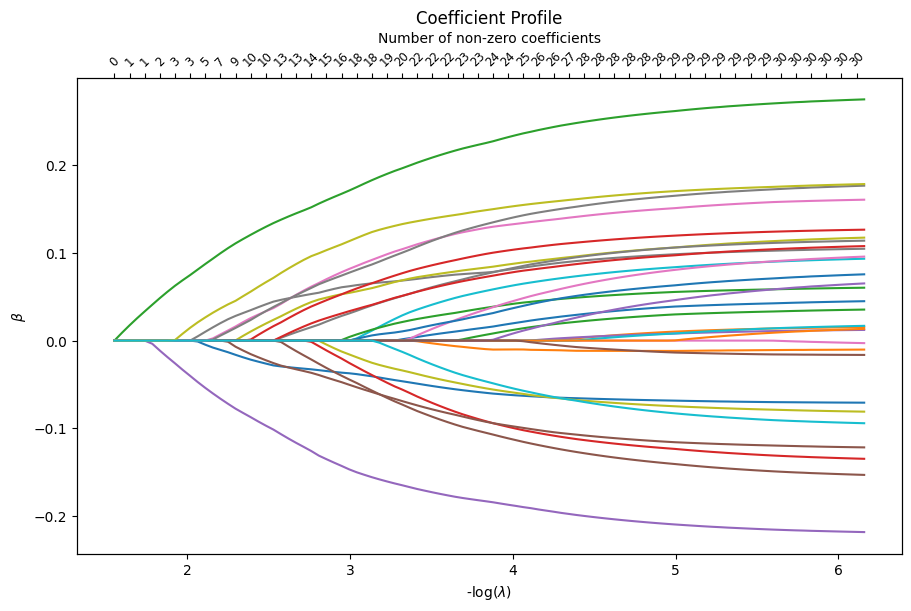

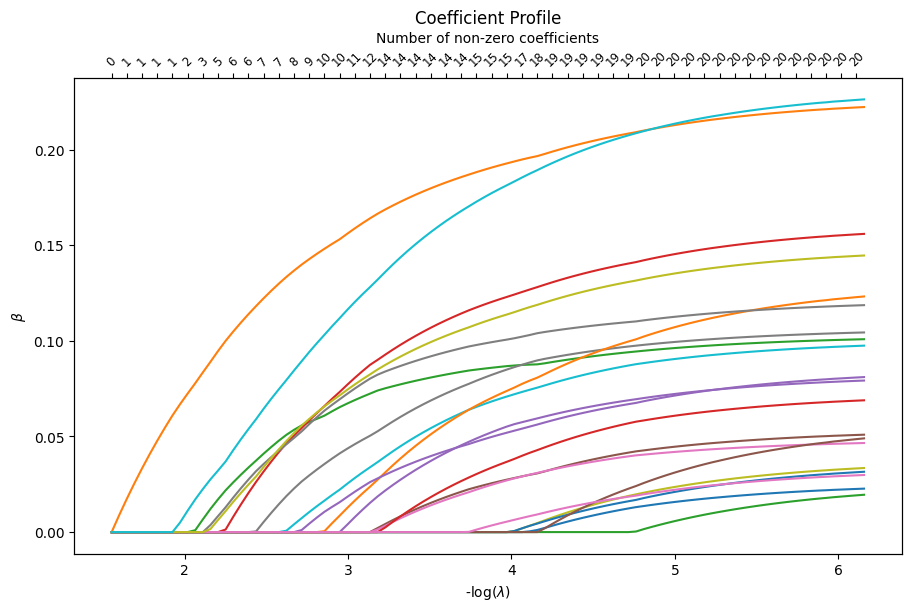

In [58]:
dg = ad.diagnostic.diagnostic(state=fit)
dg.plot_coefficients();

dg_constr = ad.diagnostic.diagnostic(state=fit_constr)
dg_constr.plot_coefficients();

### Constraints on a Single Group

Next we create a group of the first four variables. We first fit the model unconstrained, and observe the final coefficients for the first four variables. Then we put very specific constraints on each of the four coefficients in that first group, and leave the rest of the variables alone. We add blue broken lines to show these constraints. Note that we can replicate NULL constraints.

In [59]:
grps = np.append(np.array([0]), np.arange(4, 30))

fit = ad.grpnet(X, ad.glm.gaussian(y), groups = grps)
beta = fit.betas[99, 0:4]
print(beta)

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(
100%|██████████| 100/100 [00:00:00<00:00:00, 24503.80it/s] [dev:27.5%]


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4 stored elements and shape (1, 4)>
  Coords	Values
  (0, 0)	-0.07189614331451166
  (0, 1)	0.017452854489560868
  (0, 2)	0.27499982809200146
  (0, 3)	-0.13576493319117922


In [60]:
lower = np.array([-0.06, -np.inf, -np.inf, -0.1])
upper = np.array([np.inf, 0.01, 0.2, np.inf])
constr = np.array([None] * 27)
constr[0] = ad.constraint.box(lower=lower, upper=upper)

fit_constr = ad.grpnet(X, ad.glm.gaussian(y), groups = grps, constraints = constr)

100%|██████████| 100/100 [00:00:00<00:00:00, 22387.22it/s] [dev:27.0%]


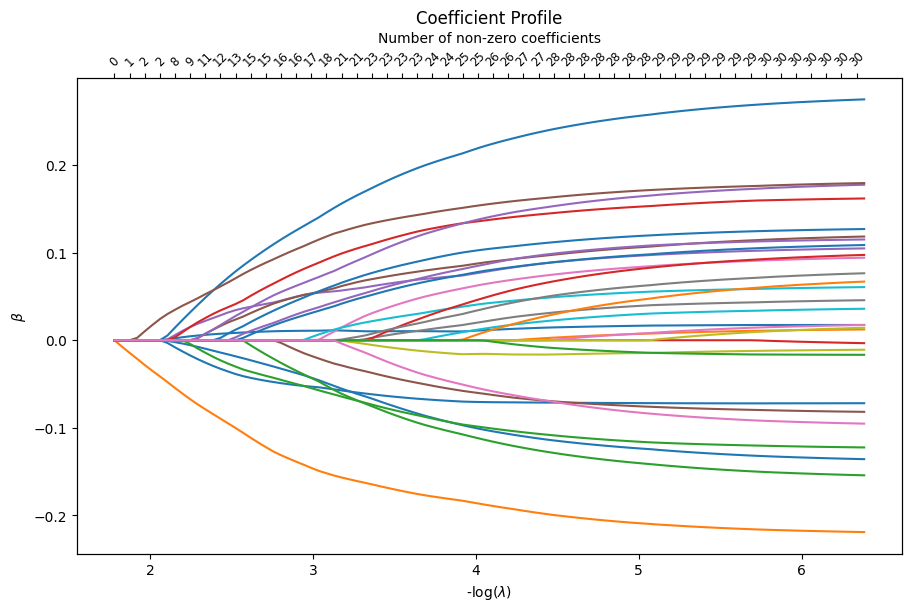

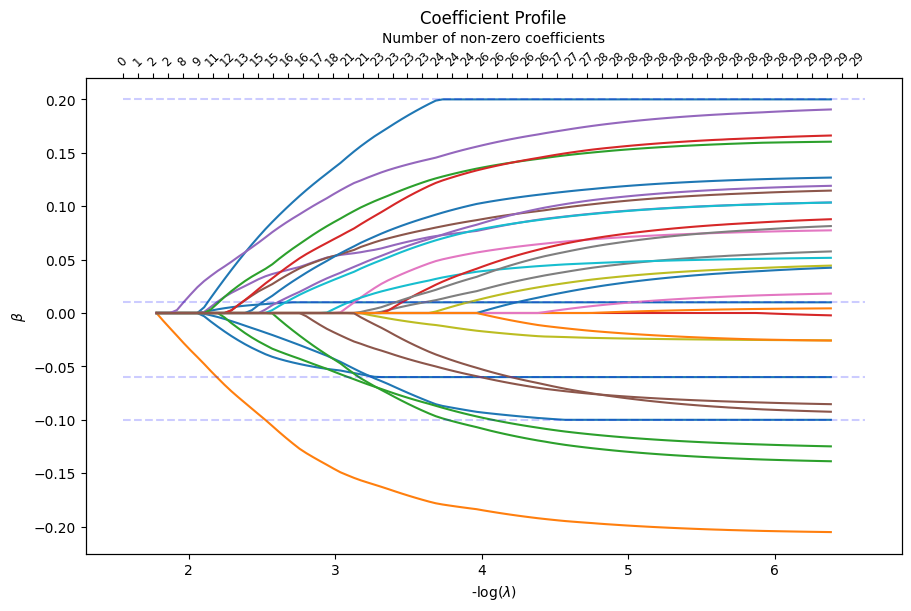

In [61]:
dg = ad.diagnostic.diagnostic(state=fit)
dg.plot_coefficients();

dg_constr = ad.diagnostic.diagnostic(state=fit_constr)
fig, ax = dg_constr.plot_coefficients();

x0, x1 = ax.get_xlim()
ax.hlines(lower, x0, x1, linestyles="--", colors="blue", alpha=0.2);
ax.hlines(upper, x0, x1, linestyles="--", colors="blue",  alpha=0.2);


## `scikit-learn`-style API

In [62]:
from sklearn.metrics import r2_score
import matplotlib.ticker as mticker

Adelie also supports a user-friendly `scikit-learn`-style API. Our `scikit-learn`-style solver is a simple wrapper of the more generic tools provided in `adelie`. Consequently, it is slightly less flexible (is supportive of GLM's like binomial and multinomial but does not currently support cox models). However, it provides many commonly used functionalities to serve as a quick drop-in replacement for many existing solvers in `scikit-learn` with `adelie`.

Here we will walk through the default settings, which solve the lasso problem with Gaussian loss.

In [63]:
n = 100     # number of observations
p = 1000    # number of features
seed = 0    # seed

np.random.seed(seed)
X = np.random.normal(0, 1, (n, p))
y = X[:, -1] * np.random.normal(0, 1) + np.random.normal(0, 1, n)

As usual, we call `fit()` with our training data `X_train` and `y_train` to solve the lasso along a path of regularization values $\lambda$.

In [64]:
model_gaussian = ad.GroupElasticNet()
model_gaussian.fit(X, y)

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(
 46%|█████     | 46/100 [00:00:00<00:00:00, 6612.12it/s] [dev:90.5%]


,solver,'grpnet'
,family,'gaussian'


We call `predict()` to compute the linear predictions for each $\lambda$. 

In [65]:
newx = X[:5,]
newy = y[:5]

predictions = model_gaussian.predict(newx)

Next, we compute the out-of-sample $R^2$ for each $\lambda$ value.

In [66]:
r2vec = np.apply_along_axis(lambda yhat: r2_score(newy, yhat), axis=1, arr=predictions)

Note that if one wants to extract the coefficents from the model themselves, it has different syntax than the standard `ad.grpnet` call. In this case, we use `.intercept_` and `.coef_` to access the optimal parameters of the model, and `.lambda_` to get the regularization path. We will demonstrate that they generate identical predictions.

In [67]:
lam_path = model_gaussian.lambda_
beta_0 = model_gaussian.intercept_
betas = model_gaussian.coef_.toarray()

manual_slopes = newx @ betas.T
manual_predictions = manual_slopes + beta_0
manual_predictions = manual_predictions.T

In [68]:
print(np.allclose(predictions, manual_predictions))

True


We can also calculate the size of the model's active set under each $\lambda$ value. This method also works for the multi-response models if one divides the degrees of freedom by the number of targets.

In [69]:
coef = model_gaussian.coef_
dof = np.sum(coef != 0, axis = 1)
dof = np.asarray(dof).ravel()         

In [70]:
dof

array([ 0,  1,  1,  1,  1,  1,  1,  2,  3,  3,  4,  4,  9, 10, 11, 12, 13,
       16, 19, 21, 24, 26, 27, 27, 28, 33, 36, 40, 44, 49, 51, 57, 58, 60,
       63, 66, 67, 67, 72, 73, 72, 74, 74, 73, 73, 72])

The `scikit-learn`-style API doesn't have as many built in diagnostics or standard plots available, however, the function `plot_validation_curve` gives a really nice visualization. It takes in the a test set along with the corresponding responses, and plots a validation curve showing $R^2$ and number of non-zero coefficients at each $\lambda$:

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(


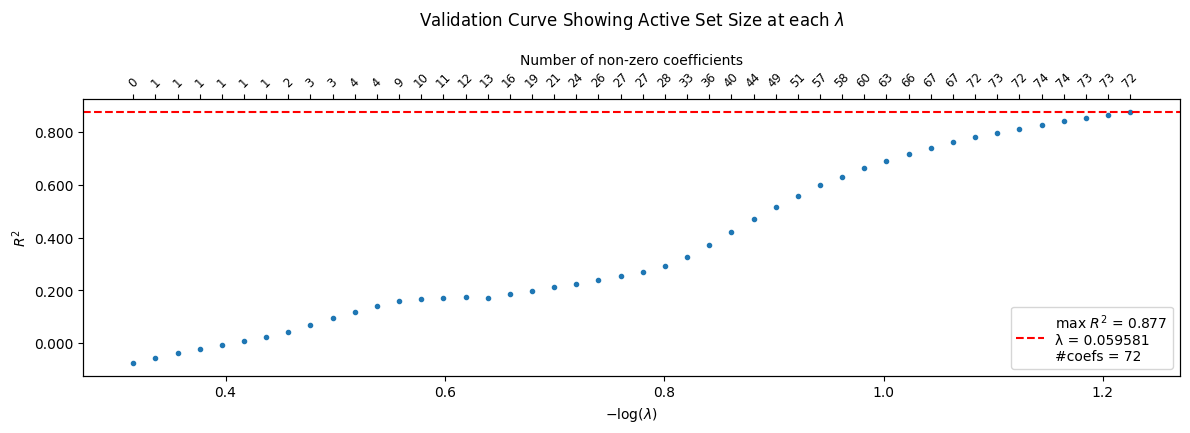

In [120]:
model_gaussian.plot_validation_curve(newx, newy)

One can even take advantage of the `adelie` diagnostic plots with a little more extra care. See the end of this section for an example of how to plot coefficient paths.

**K-Fold Cross-Validation**

More often, the user wishes to perform model selection via cross validation. If the model class is initilized with the `"cv_grpnet"` solver, we select the best $\lambda$ by k-fold cross validation and return the model at that $\lambda$.

In [73]:
model_cv_gaussian = ad.GroupElasticNet(solver="cv_grpnet")
model_cv_gaussian.fit(X, y, min_ratio=1e-3)

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(
100%|██████████| 5/5 [00:00:00<00:00:00, 6262.72it/s] [dev:7.7%]


,solver,'cv_grpnet'
,family,'gaussian'


With the `cv_grpnet` backend, calling predict automatically uses the model with the best 

In [74]:
model_cv_gaussian.predict(newx).shape

(5,)

The class also has a score method that computes $R^2$.


In [75]:
model_cv_gaussian.score(newx, newy)

0.0909820586693122

Another exciting aspect of this API is that it handles the same parameters as `ad.grpnet`. Thus if one, for example, wants to specify a lambda path or add constraints to their solver, one can do that with the appropriate call in the `.fit()` method.

In [76]:
constr = [ad.constraint.lower(b=np.array([0.0])) for _ in range(p)]

model_gaussian_nonneg = ad.GroupElasticNet()
model_gaussian_nonneg.fit(X, y, constraints = constr)

 44%|████      | 44/100 [00:00:00<00:00:00, 5042.43it/s] [dev:90.1%]


,solver,'grpnet'
,family,'gaussian'


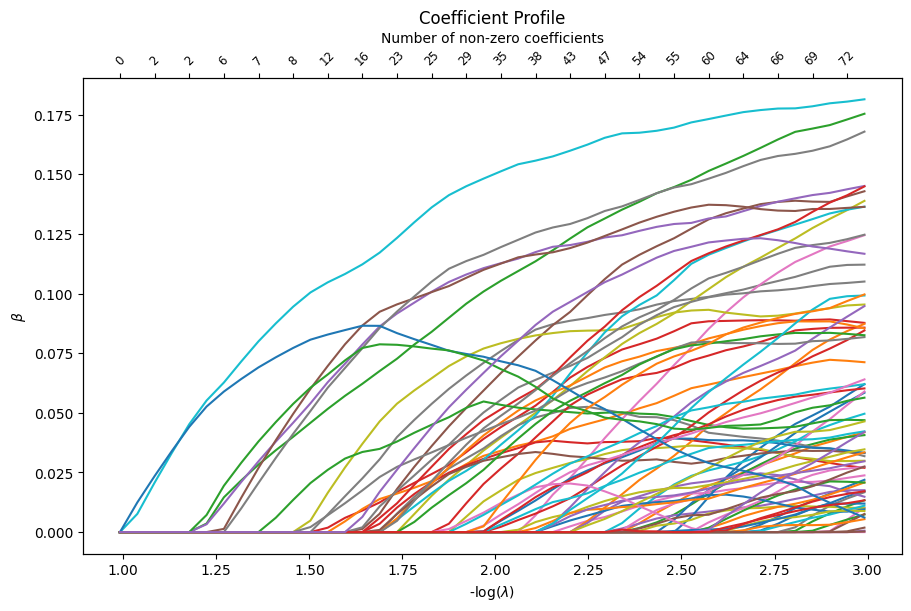

In [107]:
dg = ad.diagnostic.diagnostic(state=model_gaussian_nonneg.state_)
dg.plot_coefficients();

One must take extra care when using the `ad.diagnostic` class with the `scikit-learn`-style API. After calling `.fit()` on the `scikit-learn`–style estimator, the underlying `adelie` state is exposed as `state_`. We can then use this in calls to the diagnostic functions.

# Matrix

In group elastic net problems, the matrix object plays a crucial role in the performance of the solver. It becomes apparent in our optimization algorithm (and our benchmark analysis) that most of the runtime lies in interacting with the matrix object, e.g. computing inner-products. Hence, a highly performant matrix object implementing a select set of methods that the solver requires will yield tremendous speed gains overall. In addition, we have found numerous examples where a matrix class admits some special structure that can be exploited for further speed and memory gains. One simple example is a large sparse matrix, which cannot fit in memory as a dense matrix. Another example is genomics datasets which are not only sparse, but only take on 3 possible integer values (see [Examples], to come), and generally have over 160 billion entries with 30% non-zero entries.

For these reasons, we found it fruitful to abstract out the matrix class, and adelie provides a few examples. We discuss below some ways a user may interact with these classes.

## Matrix Attributes

Consider the case where we have a typical `adelie` matrix.

In [78]:
n = 100     # number of observations
p = 5    # number of features
seed = 0    # seed

np.random.seed(seed)
X = ad.matrix.dense(np.random.normal(0, 1, (n, p)))

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:648: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(


There are many different methods that we can use to interact with the matrix. Many of them follow the same pipeline. Here we will demonstrate how to calculate the column means of an adelie matrix. The steps taken can be repurposed for matrix methods. 

We find the column means by calling `X.mean()` but we must be aware of the arguments this function takes in. First is a vector of weights. If we simply want the column means we must pass in a vector of equal weights each $\frac{1}{n}$. Double check the documentation for the expected size of the arrays expected.

In [79]:
w = np.ones(n) / n
w.shape

(100,)

The methods usually all require a pre-allocated empty array where the output will be stores. This can simply be instantiated with the call `np.empty(p)`. In the case of the column means, we need an empty array of size $p$, one element for each column.

In [80]:
col_means = np.empty(p)

Then we call `X.mean(w, col_means)`. Note that this call does not return anything and the results are stored in the array `col_means`.

In [81]:
X.mean(w, col_means)
print(col_means)

[-0.10295661 -0.0168736  -0.05841267 -0.09427399  0.14574467]


This pipeline of pre-instantiating an empty array for the quantity of interest to be inputted into, is common with all `adelie` matrix classes.

## Some Useful Matrix Methods

We will go through a few matrix methods that will be useful in group lasso modeling.

### Dense Matrix

The simplest example of such a matrix is a dense matrix. Let us first construct a dense matrix and wrap it using `ad.matrix.dense`.



In [82]:
n = 4
p = 2
seed = 0    # seed

np.random.seed(seed)
X_dense = np.random.normal(0, 1, (n, p))
print(X_dense)

[[ 1.76405235  0.40015721]
 [ 0.97873798  2.2408932 ]
 [ 1.86755799 -0.97727788]
 [ 0.95008842 -0.15135721]]


In [83]:
Xd = ad.matrix.dense(X_dense)
print(Xd)

<adelie.matrix.dense.<locals>._dense object at 0x1570162a0>


If this is all we are going to pass to `ad.grpnet()`, then we could have saved ourselves the trouble, because it will do so anyway in the call to `grpnet`. But we will see that it can still become useful when we combine matrices.



### Sparse Matrix

Similarly, we can wrap a sparse matrix using `ad.matrix.sparse`. We will create a sparse matrix using `scipy.sparse.coo_matrix`, then convert to CSR for efficient computation. We will use the market matrix format, where we supply i, j, x triples.

In [84]:
i = np.array([1, 0, 3, 0, 1, 3])
j = np.array([0, 1, 1, 2, 2, 2])
x = np.array([0.184, 0.330, 0.738, 0.576, -0.305, 0.390])

X_sparse = coo_matrix((x, (i, j)), shape=(4, 3)).tocsr()
X_sparse

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (4, 3)>

In [85]:
print(X_sparse.toarray())

[[ 0.     0.33   0.576]
 [ 0.184  0.    -0.305]
 [ 0.     0.     0.   ]
 [ 0.     0.738  0.39 ]]


In [86]:
Xs = ad.matrix.sparse(X_sparse)
print(Xs)

<adelie.matrix.sparse.<locals>._sparse object at 0x155457ec0>


/Users/joshrichland/Desktop/adelie/adelie/matrix.py:1353: UserWarning: Converting to CSC format.
  warnings.warn("Converting to CSC format.")


### Concatenated Matrices

Suppose we have both a dense matrix and a sparse matrix. We can concatenate matrix classes together in `adelie`. This enables the software to use the most efficient methods for each when performing matrix multiplications.

In [87]:
Xds = ad.matrix.concatenate([Xd, Xs], axis = 1)
print(Xds)
print(Xds.shape)

<adelie.matrix.concatenate.<locals>._concatenate object at 0x155377330>
(4, 5)


By default we concatenated by columns. We could alternatively concatenate by rows, using the `axis=1` argument, but that would fail here since the dimensions are not compatible.



We currently do not have code that allows one to view these matrix objects; that may come in future versions of the package. There is however, a sneaky workaround that allows one to view a column of the matrix using the `ctmul` method ([link](https://jamesyang007.github.io/adelie/api_reference/generated/adelie.adelie_core.matrix.MatrixNaiveBase32.html#adelie.adelie_core.matrix.MatrixNaiveBase32.ctmul)). One can extract a column of the matrix one at a time with the following snippet.

In [88]:
col_to_extract = 0 

out = np.zeros(n)
Xds.ctmul(col_to_extract, 1, out) 
print(out)

[1.76405235 0.97873798 1.86755799 0.95008842]


Note that the above output is the first column in the dense matrix defined above, which is equivalently the first column in the concatenated matrix! If one needs the whole matrix, just loop through $j = 1, \dots, p$ to get all the columns.

In [89]:
reconstructed = []
for j in np.arange(Xds.shape[1]):
    out = np.zeros(n)
    Xds.ctmul(j, 1, out)
    reconstructed.append(out)

np.array(reconstructed).T


array([[ 1.76405235,  0.40015721,  0.        ,  0.33      ,  0.576     ],
       [ 0.97873798,  2.2408932 ,  0.184     ,  0.        , -0.305     ],
       [ 1.86755799, -0.97727788,  0.        ,  0.        ,  0.        ],
       [ 0.95008842, -0.15135721,  0.        ,  0.738     ,  0.39      ]])

Each matrix object has `attributes`, which typically contain the original matrix, or matrices if it was concatenated. ## **IS THIS TRUE??**

### Mixed Variables and One-Hot Encoding

Sometimes we have a mixture of categorical and quantitative variables. In this case we typically expand the categorical variables using *one_hot* encoding (a.k.a dummy variables). Consider the simple example where we have `X_dense` as above, along with a factor with 3 levels.



In [90]:
X_mixed = np.column_stack((X_dense, np.array([1,0,2,1])))
X_mixed

array([[ 1.76405235,  0.40015721,  1.        ],
       [ 0.97873798,  2.2408932 ,  0.        ],
       [ 1.86755799, -0.97727788,  2.        ],
       [ 0.95008842, -0.15135721,  1.        ]])

In [91]:
levels = np.array([0,0,3])

Along with this matrix we have an integer vector of levels, which says how many levels in each column, with quantitative variables depicted as 1. Notice for factors we represent the values for the factor starting at 0 in `adelie`.



In [92]:
Xoh = ad.matrix.one_hot(X_mixed, levels = levels)
n,p = Xoh.shape
Xoh.shape

/Users/joshrichland/Desktop/adelie/adelie/matrix.py:1167: UserWarning: Detected matrix to be C-contiguous. Performance may improve with F-contiguous matrix.
  warnings.warn(


(4, 5)

We would like to see what is inside `Xoh`. Since we dont have a print method yet, we will use a bit of trickery to do that, by multiplying it by the identity. This is a special alternative to the row-by-row method above. Since only row-sparse matrices are allowed (they are meant to be `adelie` coefficient matrices), we will make one.



In [93]:
out = np.zeros((p,n))

eye = coo_matrix(np.eye(p)).tocsr()
Xoh.sp_tmul(eye, out)

In [94]:
print(out.T)

[[ 1.76405235  0.40015721  0.          1.          0.        ]
 [ 0.97873798  2.2408932   1.          0.          0.        ]
 [ 1.86755799 -0.97727788  0.          0.          1.        ]
 [ 0.95008842 -0.15135721  0.          1.          0.        ]]


### Standardization

We typically wish to standardize the features before fitting an `adelie` model, with a few exceptions. If some columns represent the *one-hot* vectors for a factor variable, we generally do not standardize them. Lets use that case as an example. Each matrix class has its own standardize method.



In [95]:
Xohs = ad.matrix.standardize(Xoh)

out = np.zeros((p,n))

eye = coo_matrix(np.eye(p)).tocsr()
Xohs.sp_tmul(eye, out)
print(out.T)

[[ 0.87495404  0.01865874  0.          1.          0.        ]
 [-0.96252834  1.57605374  1.          0.          0.        ]
 [ 1.11713705 -1.14675038  0.          0.          1.        ]
 [-1.02956274 -0.44796211  0.          1.          0.        ]]


# Additional Capabitlies

## Warm Start

When solving models along a sequence of regularization parameters, you can use a warm start to initialize the solver with a previous fit. This can speed up computation and ensure smoother convergence when extending or refining a $\lambda$-path.

In [96]:
n = 100     # number of observations
p = 1000    # number of features
seed = 0    # seed

np.random.seed(seed)
X = np.random.normal(0, 1, (n, p))
y = X[:, -1] * np.random.normal(0, 1) + np.random.normal(0, 1, n)

Consider a standard Lasso fit with a moderate convergence tolerance, simulating a scenario where the model doesn't fully converge.

In [97]:
old_state = ad.grpnet(
    X=X,
    glm=ad.glm.gaussian(y=y),
    adev_tol = 0.4
)

 21%|██        | 21/100 [00:00:00<00:00:00, 3167.96it/s] [dev:42.1%]


To demonstrate the benefits of warm start, we'll use the result of our previous solve as an initialization point for a new solve with stricter convergence criteria.

In [98]:
warmed_state = ad.grpnet(
    X=X,
    glm=ad.glm.gaussian(y=y),
    adev_tol = 1,
    warm_start = old_state
)

100%|██████████| 100/100 [00:00:00<00:00:00, 3845.72it/s] [dev:99.9%]


With the warm start, the solver achieves a higher percent deviance explained and completes in fewer iterations, demonstrating the efficiency gains of this technique. This is particularly useful when computing extended solution paths or when fine-tuning models with different regularization parameters.

## Covariance Method

For least squares specifically, we expose an equivalent solver `ad.solver.gaussian_cov` that 
uses summary statistics rather than individual-level data.

We show below how to solve the equivalent problem presented in the previous sections.
First, we create the summary statistics based on the individual-level data.

In [99]:
n = 100     # number of observations
p = 1000    # number of features
seed = 0    # seed

np.random.seed(seed)
X = np.random.normal(0, 1, (n, p))
y = X[:, -1] * np.random.normal(0, 1) + np.random.normal(0, 1, n)

In [100]:
Xc = X - np.mean(X, axis=0)[None]
yc = y - np.mean(y)
A = Xc.T @ Xc / n
v = Xc.T @ yc / n

Now, we use `gaussian_cov` to solve the Gaussian group elastic net problem.

In [101]:
state_cov = ad.gaussian_cov(
    A=A,
    v=v,
    groups=10*np.arange(A.shape[-1] // 10),
)

 63%|██████    | 63/100 [00:00:00<00:00:00, 2281.45it/s] [rdev:0.1%]


Note that the progress bar displays a different measurement of deviance explained.
For the covariance method, since it is usually infeasible to compute the loss at the saturated model,
we only display the relative change in percent deviance explained
(which can be computed without knowledge of the saturated loss):
$$
\begin{align*}
    \mathrm{rdev} 
    := 
    \frac{
        \ell(\beta_{\mathrm{prev}}) - \ell(\beta_{\mathrm{curr}})
    }{
        \ell(\beta_{\mathrm{null}}) - \ell(\beta_{\mathrm{curr}})
    }
\end{align*}
$$
so that a $\mathrm{rdev}$ close to zero indicates overfitting.
In this example, we early exit the solver once $\mathrm{rdev}$ reaches $0.1\%$.

We can compare the solution with that of the result of `grpnet`.

In [102]:
state = ad.grpnet(
    X=X,
    glm=ad.glm.gaussian(y=y),
    groups=10*np.arange(X.shape[-1] // 10),
)

 38%|████      | 38/100 [00:00:00<00:00:00, 5322.72it/s] [dev:90.2%]


In [103]:
n_common_sols = min(state_cov.betas.shape[0], state.betas.shape[0])
assert np.allclose(
    state_cov.betas[:n_common_sols].toarray(),
    state.betas[:n_common_sols].toarray(),
    atol=1e-3,
)

## Benchmark Timings

Serious developers may be interested in the performance of the solver. We also provide a function to inspect the benchmark timings of the solver at each $\lambda$.

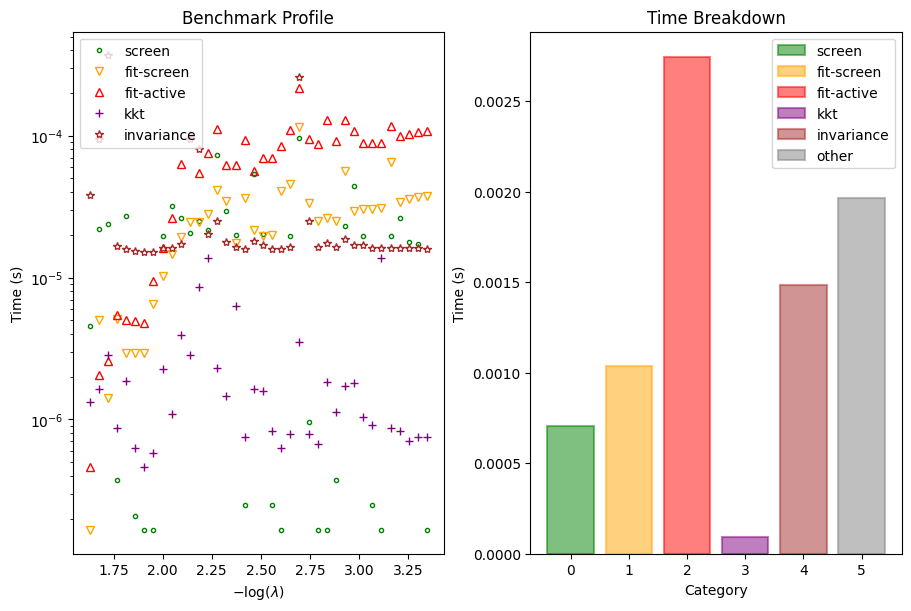

In [104]:
dg = ad.diagnostic.diagnostic(state=state)
dg.plot_benchmark()
plt.show()

# __Global Configurations__

Global configurations can be toggled via `ad.configs.set_configs` function.

To change the progress bar symbol, the user can run the following with the last argument being the desired symbol:

In [105]:
ad.configs.set_configs("pb_symbol", "\U0001f427")

Now, the progress bar will print penguins!

In [106]:
state = ad.grpnet(
    X=X,
    glm=ad.glm.gaussian(y=y, dtype=np.float64),
)

 46%|🐧🐧🐧🐧🐧     | 46/100 [00:00:00<00:00:00, 4357.76it/s] [dev:90.5%]
